## Motivation:
Repeat the previous experiments, but with a PPO agent.

## Attack:
- Shrew attack with an RPS of 100. *This time launched from a virtual machine.*
- Commenced *shortly after 'normal operation' starts*.

## Policy:
- "blue -t 10.0 -f 0.8 -i 0.05 -s 5.0 --server-policy"

In [55]:

import plot_utils
from plot_utils import LogFile,LogFileType,Fig,Roller
import rolling_funcs

# WINDOW_SECS=120.0
WINDOW_SECS=480.0
STRIDE_SECS=5.0
# WINDOW_SECS=3.0
# STRIDE_SECS=-1.0

In [56]:

response_rollers = [
    Roller("OK rate", rolling_funcs.count_ok, rate=True),
    Roller("ERR rate", rolling_funcs.count_err, rate=True, kwargs={'linestyle':'--'}),
]
mean_roller = Roller('mean', rolling_funcs.mean)
packet_rate = Roller('rate', rolling_funcs.count_kleene_packets, rate=True)

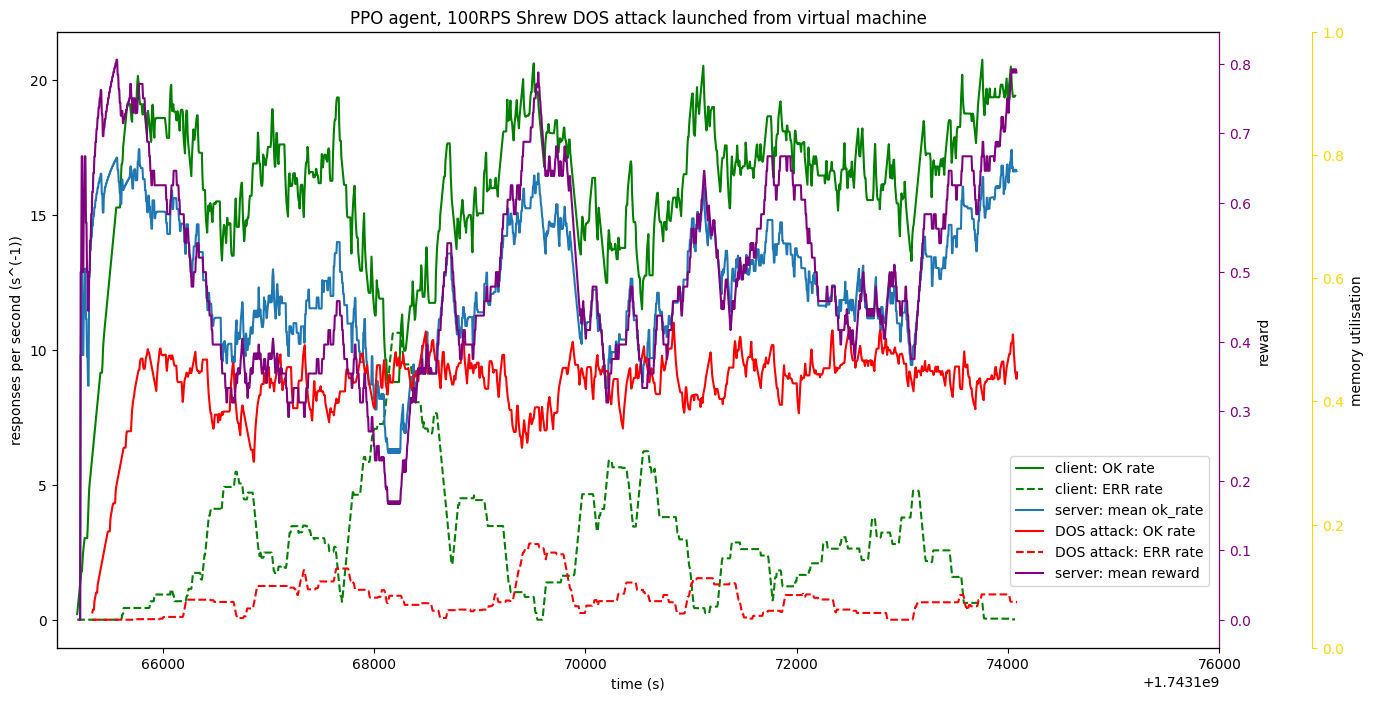

In [65]:
HILBERT="./logs/hilbert/2025-03-28_15:18:25.json"
HILBERT_BLUE="./logs/hilbert/2025-03-28_12-33-29.825657.txt"
KLEENE="./logs/kleene/2025-03-28_12-33-06.820085.txt"
KLEENE_TELEGRAF="./logs/kleene/2025-03-28_15:18:25.json"
POST="./logs/post/2025-03-28_12-35-30.581185.txt"

fig,ax = plot_utils.fig([Fig(title="PPO agent, 100RPS Shrew DOS attack launched from virtual machine",x='time (s)',y='responses per second (s^(-1))')])
ax.set_xlim(65000+1.7431e9,76000+1.7431e9)

nginx_active = LogFile(log_type=LogFileType.TELEGRAF, path=HILBERT,
kwargs={'telegraf': {
    'nginx' : ['active', 'waiting']
}
})

client_mem = LogFile(log_type=LogFileType.TELEGRAF, path=KLEENE_TELEGRAF,
kwargs={'telegraf':{
    # 'mem' : ['used_percent','buffered','cached','vmalloc_used']
    'mem' : [{'used_percent':{'color':'gold'}}]
}})

client_log = LogFile(log_type=LogFileType.GOT, path=KLEENE,kwargs={'color':'g'})
shrew_log = LogFile(log_type=LogFileType.GOT, path=POST,kwargs={'color':'r'})

blue_reward = LogFile(log_type=LogFileType.BLUE, path=HILBERT_BLUE,
kwargs={'states': [{'reward':{'color':'purple'}}]})

blue_ok_rate = LogFile(log_type=LogFileType.BLUE, path=HILBERT_BLUE,
kwargs={'states': ['ok_rate']})

# blue_actions = LogFile(log_type=LogFileType.BLUE, path=HILBERT_BLUE,
# kwargs={'actions': True
# })

ax_reward, ax_mem = plot_utils.add_y_axes(
    ax, [('reward','purple'), ('memory utilisation','gold')]
)

# plot_utils.overlay_rolling(ax_active, {'server': nginx_active}, [mean_roller],WINDOW_SECS,times_units='s')
plot_utils.overlay_rolling(ax_reward, {'server': blue_reward}, [mean_roller],WINDOW_SECS, const_stride_secs=STRIDE_SECS, times_units='s')
# plot_utils.overlay_rolling(ax_mem, {'client': client_mem}, [mean_roller],WINDOW_SECS,times_units='s')
plot_utils.overlay_rolling(ax, {'client': client_log, }, response_rollers, WINDOW_SECS, const_stride_secs=STRIDE_SECS, times_units='s')
plot_utils.overlay_rolling(ax, {'server': blue_ok_rate}, [mean_roller],WINDOW_SECS, const_stride_secs=STRIDE_SECS, times_units='s')
plot_utils.overlay_rolling(ax, {'DOS attack': shrew_log, }, response_rollers, WINDOW_SECS, const_stride_secs=STRIDE_SECS, times_units='s')

plot_utils.show_combined_legends([ax,ax_reward,ax_mem], loc=[0.82,0.1])
fig.savefig('./plots/virtual_ppo.png')

In [58]:
from blue import Blue
blue = Blue(HILBERT_BLUE)
end_of_exploration = (74000+1.7431e9) 
blue.stats(sorted=True,end_ns=end_of_exploration*1e9)

[('red_blocked', 219),
 ('none_blocked', 216),
 ('both_blocked', 0),
 ('green_blocked', 0)]

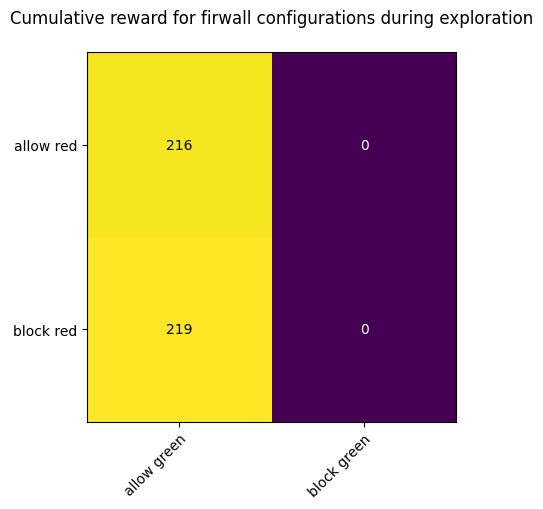

In [59]:
fig,ax = blue.heatmap(title="Cumulative reward for firwall configurations during exploration\n", end_ns=end_of_exploration*1e9)
fig.savefig('./plots/policy_heatmap.png')